## Clustering-Map-Refine 요약

##### Map-Refine 방식에 클러슽링(군집화) 단계를 붙인것

- 클러스터링: 문서들을 임베딩해서 내용이 비슷한 문서끼리 묶음
- map-refine: 각 클러스터링 안에 문서를 하나씩 추가하면서 요약 갱신

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_community.document_loaders import PyPDFLoader

docs = PyPDFLoader("data/SPRI_AI_Brief_2023년12월호_F.pdf").load()

In [4]:
texts = "\n\n".join([doc.page_content for doc in docs])

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

split_docs = text_splitter.split_text(texts)

In [9]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

vectors = embeddings.embed_documents(split_docs)

In [12]:
#임베딩된 벡터를 가지고 10개의 클러스터로 나눔
#KMeans 알고리즘 이용함

from sklearn.cluster import KMeans

num_clusters = 10

kmeans = KMeans(n_clusters=num_clusters, random_state=123).fit(vectors)

In [13]:
kmeans.labels_

array([3, 4, 7, 4, 4, 4, 4, 4, 1, 4, 4, 4, 1, 1, 2, 1, 1, 1, 1, 1, 7, 7,
       7, 7, 7, 7, 7, 7, 2, 2, 2, 2, 2, 2, 2, 2, 4, 9, 9, 9, 4, 4, 2, 4,
       8, 8, 8, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 1, 1, 1, 4,
       6, 6, 6, 6, 6, 6, 6, 4, 6, 4, 4, 4, 7], dtype=int32)

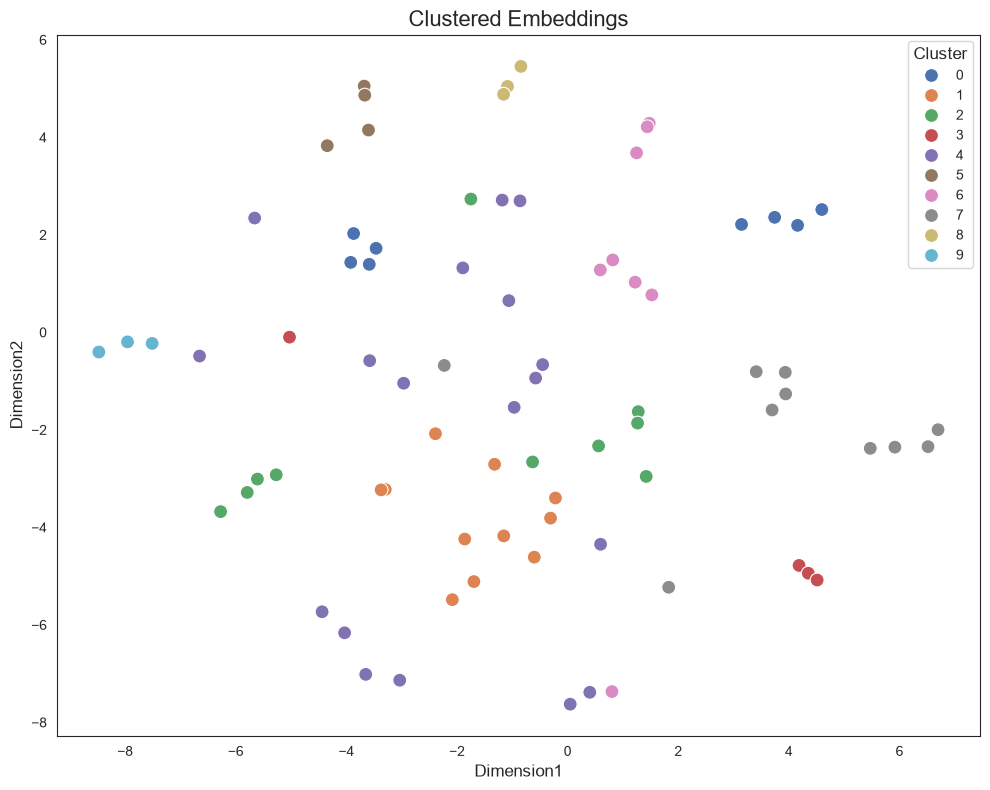

In [15]:
#클러스터링 결과를 2차원 그래프로 시각화

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings #경고 제거

warnings.filterwarnings("ignore")

#t-SNE 수행 및 2차원으로 축소
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

sns.set_style("white")

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=reduced_data_tsne[:, 0],
    y=reduced_data_tsne[:, 1],
    hue=kmeans.labels_,
    palette="deep",
    s=100
)

plt.xlabel("Dimension1", fontsize = 12)
plt.ylabel("Dimension2", fontsize = 12)
plt.title("Clustered Embeddings", fontsize = 16)
plt.legend(title="Cluster",title_fontsize=12)

plt.gcf().patch.set_facecolor("white") #배경색

plt.tight_layout()
plt.show()

In [17]:
#각 클러스터의 중심점을 찾아야함
#그 중심점과 임베딩 값이 가장 가까운 문서를 찾아 저장

import numpy as np

closest_indices = []

for i in range(num_clusters):
    distances = np.linalg.norm(vectors -kmeans.cluster_centers_[i], axis=1)
    closest_index = np.argmin(distances)
    closest_indices.append(closest_index)

In [18]:
closest_indices

[np.int64(53),
 np.int64(17),
 np.int64(34),
 np.int64(59),
 np.int64(4),
 np.int64(48),
 np.int64(68),
 np.int64(24),
 np.int64(44),
 np.int64(38)]

In [19]:
selected_indices = sorted(closest_indices)
selected_indices

[np.int64(4),
 np.int64(17),
 np.int64(24),
 np.int64(34),
 np.int64(38),
 np.int64(44),
 np.int64(48),
 np.int64(53),
 np.int64(59),
 np.int64(68)]

In [20]:
from langchain_core.documents import Document

selected_docs = [Document(page_content=split_docs[doc]) for doc in selected_indices]
selected_docs

[Document(metadata={}, page_content='▹ 빌 게이츠, AI 에이전트로 인한 컴퓨터 사용의 패러다임 변화 전망 ································13\n   ▹ 유튜브, 2024년부터 AI 생성 콘텐츠 표시 의무화 ····························································14\n 3. 기술/연구\n   ▹ 영국 과학혁신기술부, AI 안전 연구소 설립 발표 ······························································15\n   ▹ 구글 딥마인드, 범용 AI 모델의 기능과 동작에 대한 분류 체계 발표 ······························16\n   ▹ 갈릴레오의 LLM 환각 지수 평가에서 GPT-4가 가장 우수 ···········································17\n   \n 4. 인력/교육'),
 Document(metadata={}, page_content='∙ 선언은 AI 안전 보장을 위해 국가, 국제기구, 기업, 시민사회, 학계를 포함한 모든 이해관계자의 협력이 \n중요하다고 강조했으며, 특히 최첨단 AI 시스템 개발 기업은 안전 평가를 비롯한 적절한 조치를 취하여 \nAI 시스템의 안전을 보장할 책임이 있다고 지적\n∙ 각국은 AI 안전 보장을 위해 첨단 AI 개발기업의 투명성 향상, 적절한 평가지표와 안전 테스트 도구 \n개발, 공공부문 역량 구축과 과학 연구개발 등의 분야에서 협력하기로 합의\n£ 영국 총리, 정부 주도의 첨단 AI 시스템 안전 테스트 계획 발표\nn 리시 수낙 영국 총리는 AI 안전성 정상회의를 마무리하며 첨단 AI 모델에 대한 안전성 시험 계획 \n수립과 테스트 수행을 주도할 영국 AI 안전 연구소의 출범을 발표\n∙ 첨단 AI 모델의 안전 테스트는 국가 안보와 안전, 사회적 피해를 포함한 여러 잠재적 유해 기능에 대한 \n시험을 포함하

In [ ]:
#Map-Refine 체인 만들기
#map: 첫번째 문서를 요약함
#refine: 기존 요약 + 다음 문서를 보고 요약을 계속 보완함
#클러스터별 대표 문서(selected_docs)를 순서대로 넣어서 최종 요약을 만듦

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

#요약에 사용할 LLM (temperature=0 → 매번 비슷한 답변)
llm = ChatOpenAI(
    temperature=0,
    model_name="gpt-4o-mini"
)

#map prompt: 첫번째 문서 요약용
map_prompt = ChatPromptTemplate.from_template("""
다음 문서의 내용을 요약하세요.

문서:
{context}

한국어로 답변하세요.
""")

#map chain 생성 (프롬프트 → LLM → 문자열로 변환)
map_chain = map_prompt | llm | StrOutputParser()

#refine prompt: 기존 요약에 새로운 문서 내용을 반영하는 용도
refine_prompt = ChatPromptTemplate.from_template("""
기존 요약:
{existing_summary}

새로운 문서:
{context}

새로운 문서의 내용을 기존 요약에 반영하여
더 정확하고 완전한 요약을 작성하세요.

기존 요약에서 새로운 문서와 관련 없는 내용은
가능하면 유지하고, 새로운 정보가 있다면 추가하세요.

한국어로 답변하세요.
""")

#refine chain 생성
refine_chain = refine_prompt | llm | StrOutputParser()


def map_refine(docs):
    #1. map 단계: 첫번째 문서만 먼저 요약
    summary = map_chain.invoke({"context": docs[0].page_content})

    #2. refine 단계: 두번째 문서부터 하나씩 추가하면서 요약 보완
    for doc in docs[1:]:
        summary = refine_chain.invoke({
            "existing_summary": summary,
            "context": doc.page_content
        })

    #최종 요약 반환
    return summary


#일반 함수를 체인처럼 .invoke()로 쓸 수 있게 감싸줌
map_refine_chain = RunnableLambda(map_refine)

In [ ]:
#클러스터별 대표 문서 10개를 map-refine 체인에 넣어서 최종 요약 생성
refined_summary = map_refine_chain.invoke(selected_docs)

In [ ]:
#최종 요약 결과 출력
print(refined_summary)